# Class 02: Cow Behaviour Classification
The goal of this notebook is to classify cow behaviours using raw sensor data collected by the RumiWatch system. The RumiWatch sensor records accelerometer (x, y, z axes) and pressure data, along with temperature. These measurements are used to train supervised machine learning models that predict cow behaviour states.

We will use a dataset containing different behaviour labels, which we will predict.

The workflow includes:
- Loading and preprocessing the raw sensor data.
- Mapping integer labels to cow behaviour categories.
- Splitting the data into train and test sets.
- Training classification models (e.g., Random Forest).
- Evaluating model performance.
- Analyzing feature importance to understand which sensor measurements contribute most to behaviour prediction.

---

**Instructions:**  
Follow the notebook step-by-step and complete the TASKS where indicated. For each code cell marked with `# Add your code here`, write the required Python code to perform the analysis. Use the provided variable names.

## Import required libraries
Import necessary libraries for data processing, model training, and visualization.

In [1]:
import zipfile

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

## Load data
Below the compressed dataset is loaded into a pandas DataFrame.
The dataset contains raw sensor measurements and corresponding behaviour labels from a single dairy cow equipped with a RumiWatch sensor.

In [2]:
zip_path = "../data/raw/rwu_275a_1_convert_10hz.zip"
csv_filename = "rwu_275a_1_convert_10hz.csv"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_filename) as f:
        df_data = pd.read_csv(f, sep=';')


# Drop columns where all values are NaN
df_data = df_data.dropna(axis=1, how="all")

print(df_data.head())


                    time  pressure  move_x  move_y  move_z  temperature  \
0  05.09.2019 11:30:04.0      3207      -2      13      54         1748   
1  05.09.2019 11:30:04.1      3213      -2      12      54         1748   
2  05.09.2019 11:30:04.2      3210      -2      12      54         1748   
3  05.09.2019 11:30:04.3      3211      -3      12      54         1748   
4  05.09.2019 11:30:04.4      3208      -3      12      53         1748   

   peak_time  classification  
0      19581               0  
1      19581               0  
2      19581               0  
3      19581               0  
4      21177               0  


In order to avoid any unreliable sensor data (habituation for the cow), the first 2 hours since start of the measurements will be dropped. 

In [3]:
# Drop 1st 2hours of data
df_data = df_data.iloc[2*60*60*10:]

## Data exploration and preprocessing

### Overview of the variables

Below an overview of the dataset is provided.

| Variable       | Description                                  |
|----------------|----------------------------------------------|
| time           | Logging date and time (DD.MM.YYYY, hh:mm:ss) |
| pressure       | Pressure value                               |
| move_x         | Acceleration in x-axis                       |
| move_y         | Acceleration in y-axis                       |
| move_z         | Acceleration in z-axis                       |
| temperature    | Temperature value                            |
| peak_time      | RumiWatch Unit internal counter              |
| classification | Classification of the metered data           |

**Classification mapping:**

The integer labels in the `classification` column correspond to the following cow behaviours:

| Label | Meaning        |
|-------|----------------|
| 0     | Other activity |
| 1     | Ruminating     |
| 2     | Feed intake    |
| 4     | Water intake   |

The goal is to predict the `classification` label using the sensor measurements as features. Having a reliable classification label is crucial before any model can be trained. Typically, the classification is done by trained experts who visually observe the cow and annotate the sensor data accordingly.

### Summary of the dataset

**TASK**\
Make a summary of the dataset.

In [4]:
# Add your code here

### Visualize class distributions
**TASK**
Visualize the class distributions.

In [6]:
# Add your code here

For this exercise we will combine class 4 into 2 as "ingestive behaviour".

In [8]:
# Add class 4 to "feed intake" (class 2)
df_data["classification"] = df_data["classification"].replace(4, 2)


To facilitate interpretation we will add a class mapping.

In [9]:
# Map class numbers to behaviour labels
class_mapping = {
    0: "Other activity",
    1: "Rumination",
    2: "Ingestive behaviour"
}

# Add readable behaviour column
df_data["behaviour"] = df_data["classification"].map(class_mapping)

# Quick check
print(df_data[["classification", "behaviour"]].drop_duplicates().sort_values("classification"))

       classification            behaviour
72000               0       Other activity
72698               1           Rumination
72498               2  Ingestive behaviour


### Visualize sensor data over time
Plot with 1 hour of movement data over time: 
- Series: `move_x`, `move_y`, and `move_z` and `pressure`.  
- Shaded vertical background regions to indicate classification labels. 

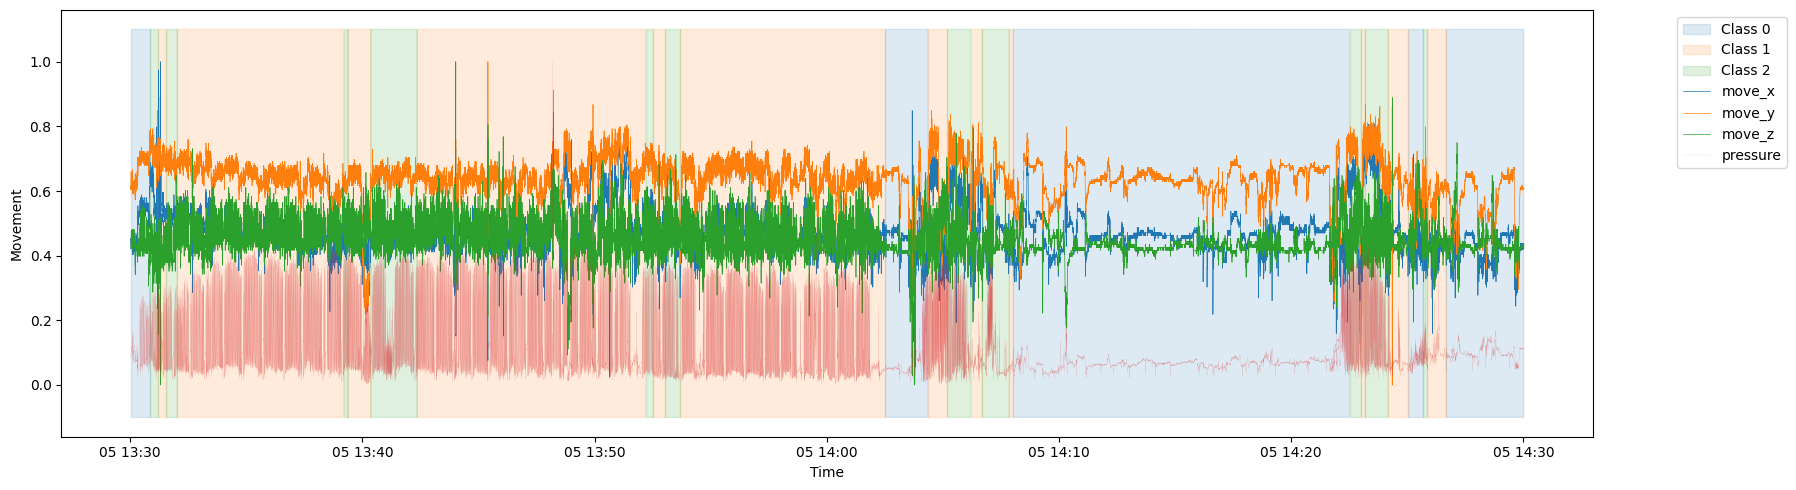

In [10]:
n_obs = 1 * 60 * 60 * 10
time = pd.to_datetime(df_data["time"], format="%d.%m.%Y %H:%M:%S.%f")[:n_obs]
move_x = (df_data['move_x'][:n_obs] - df_data['move_x'][:n_obs].min()) / (df_data['move_x'][:n_obs].max() - df_data['move_x'][:n_obs].min())  # Center move_x around zero
move_y = (df_data['move_y'][:n_obs] - df_data['move_y'][:n_obs].min()) / (df_data['move_y'][:n_obs].max() - df_data['move_y'][:n_obs].min())  # Center move_y around zero
move_z = (df_data['move_z'][:n_obs] - df_data['move_z'][:n_obs].min()) / (df_data['move_z'][:n_obs].max() - df_data['move_z'][:n_obs].min())  # Center move_z around zero
pressure = (df_data['pressure'][:n_obs] - df_data['pressure'][:n_obs].min()) / (df_data['pressure'][:n_obs].max() - df_data['pressure'][:n_obs].min())  # Center pressure around zero
classes = df_data['classification'][:n_obs]
unique_classes = np.unique(classes)

fig, ax = plt.subplots(figsize=(18, 5))

colors = plt.cm.tab10.colors

# Plot classification background bands
for cls in unique_classes:
    mask = classes == cls
    y_min = pressure.min() - 0.1
    y_max = pressure.max() + 0.1

    ax.fill_between(
        time,
        y_min,
        y_max,
        where=mask.to_numpy(),
        color=colors[int(cls) % len(colors)],
        alpha=0.15,
        label=f'Class {cls}'
    )

# Plot move_x, move_y, move_z, and pressure on the same axis
ax.plot(time, move_x, label='move_x', color='tab:blue', linewidth=0.5)
ax.plot(time, move_y, label='move_y', color='tab:orange', linewidth=0.5)
ax.plot(time, move_z, label='move_z', color='tab:green', linewidth=0.5)
ax.plot(time, pressure, label='pressure', color='tab:red', linewidth=0.05)

# Combine legends (only one axis now)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Time')
ax.set_ylabel('Movement')

plt.tight_layout()
plt.show()

## Train-Test Split

In this section, you will select the features and classification for model training, and perform a train/test split.

**TASK**

Split the dataset in a train and test dataset and assign it respectively to train and test.
For the test set, use the last 5 days of data. Although we respect the temporal aspect when splitting the timeseries, there is one crucial limitation in this dataset and train - test split, (mostly in order to limit the training time), what is this limitation?

In [11]:
# Add here your code

## Feature Engineering: Data Segmentation and Feature Calculation

In order to perform classification, a first step is segmentation of the raw sensor data into fixed time windows and calculation of statistical features from each window. This approach transforms continuous time-series data into a structured feature matrix suitable for machine learning models.

### Windowing and Feature Extraction

The sensor data will be segmented into 60-second windows. For each window, we extract statistical features from the accelerometer (move_x, move_y, move_z) and pressure measurements:

**Features extracted per window:**
For this exercise we only calculated a limited number of features, feel free to add features. The Python package tsfresh allows to calculate many more features in an automated way.

Some important **Derived features:**: 

Signal Vector Magnitude (SVM): $\sqrt{\bar{x}^2 + \bar{y}^2 + \bar{z}^2}$
Signal Magnitude Area (SMA): $\sum(|\bar{x}| + |\bar{y}| + |\bar{z}|)$

Overall Dynamic Body Acceleration (ODBA): 
A proxy for activity level, computed as the sum of absolute dynamic acceleration across all three axes:

$$\mathrm{ODBA} = |a_x - \mu_x| + |a_y - \mu_y| + |a_z - \mu_z|$$

where $a_x, a_y, a_z$ are instantaneous accelerations and $\mu_x, \mu_y, \mu_z$ are their smoothed/static components.

The most frequent classification label within each window is assigned as the window's class label. This generates a balanced feature matrix with the engineered features and corresponding behaviour labels.

In [13]:
def compute_odba_xyz(ax, ay, az, alpha=0.10):
    """
    Compute ODBA from tri-axial accelerometer data and return
    both the ODBA time series and its mean.

    Parameters
    ----------
    ax, ay, az : array-like
        Acceleration measurements along x, y, z axes.
    alpha : float, default=0.10
        EMA smoothing factor.

    Returns
    -------
    odba : np.ndarray
        ODBA time series.
    mean_odba : float
        Mean ODBA over the entire recording.
    """

    ax = np.asarray(ax, dtype=float)
    ay = np.asarray(ay, dtype=float)
    az = np.asarray(az, dtype=float)

    if not (len(ax) == len(ay) == len(az)):
        raise ValueError("ax, ay, and az must have the same length")

    def ema(x):
        mu = np.empty_like(x)
        mu[0] = x[0]
        for i in range(1, len(x)):
            mu[i] = alpha * x[i] + (1 - alpha) * mu[i - 1]
        return mu

    sx = ema(ax)
    sy = ema(ay)
    sz = ema(az)

    dx = ax - sx
    dy = ay - sy
    dz = az - sz

    odba = np.abs(dx) + np.abs(dy) + np.abs(dz)
    mean_odba = float(np.mean(odba))

    return mean_odba

In [14]:
def extract_window_features(
    df,
    n_seconds=60,
    sampling_rate=10,
    label_col="classification"
):
    window_size = n_seconds * sampling_rate
    n_windows = len(df) // window_size

    features = []
    labels = []
    purities = []

    for i in range(n_windows):
        window = df.iloc[i * window_size:(i + 1) * window_size]

        # =========================
        # PRESSURE FEATURES
        # =========================
        pressure_series = window["pressure"]
        mean_pressure = np.mean(window["pressure"])
        range_pressure = np.max(window["pressure"]) - np.min(window["pressure"])

        # =========================
        # ACCELEROMETER FEATURES
        # =========================
        acc_mag = np.sqrt(
            window["move_x"]**2 +
            window["move_y"]**2 +
            window["move_z"]**2
        )
        mean_odba = compute_odba_xyz(window["move_x"], window["move_y"], window["move_z"], alpha=0.15)
                
        svm = np.mean(acc_mag)
        svm_sum = np.sum(acc_mag)
        svm_std = np.std(acc_mag)

        sma = (
            np.abs(window["move_x"]).mean()
            + np.abs(window["move_y"]).mean()
            + np.abs(window["move_z"]).mean()
        )

        # =========================
        # FEATURE VECTOR
        # =========================
        features.append({
            # pressure stats
            "mean_pressure": mean_pressure,
            "range_pressure": range_pressure,

            # movement
            "odba": mean_odba,

            "svm": svm,
            "svm_sum": svm_sum,
            "svm_std": svm_std,
            "sma": sma
        })

        label_distribution = window[label_col].value_counts(normalize=True)
        majority_label = label_distribution.index[0]
        purity = label_distribution.iloc[0]

        labels.append(majority_label)
        purities.append(purity)

    return pd.DataFrame(features), pd.Series(labels), pd.Series(purities, name="purity")

We apply the feature extraction function to the training and test sets.

In [15]:
X_train, y_train, w_train_purity = extract_window_features(train)
X_test, y_test, w_test_purity = extract_window_features(test)

print(f'Train shape {X_train.shape}, Test shape {X_test.shape}')
print('Train purity summary:')
display(w_train_purity.describe())

Train shape (14202, 7), Test shape (7200, 7)
Train purity summary:


count    14202.000000
mean         0.953588
std          0.122364
min          0.333333
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: purity, dtype: float64

**TASK**

Visualize the features in relation to the target variable.

In [16]:
# Add your code here

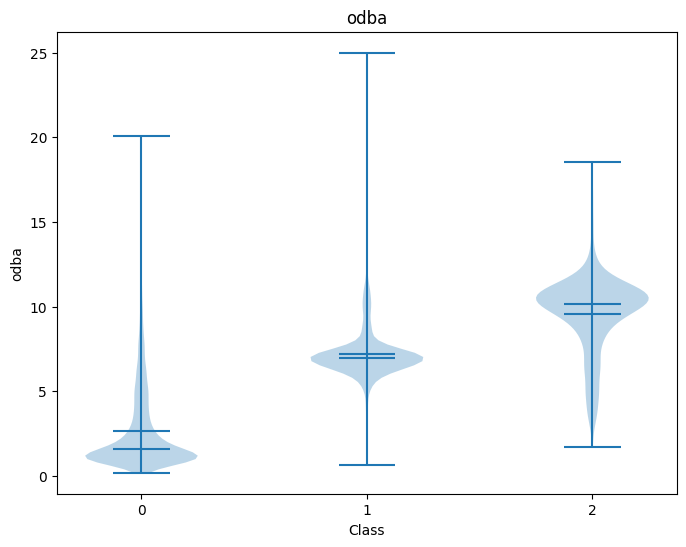

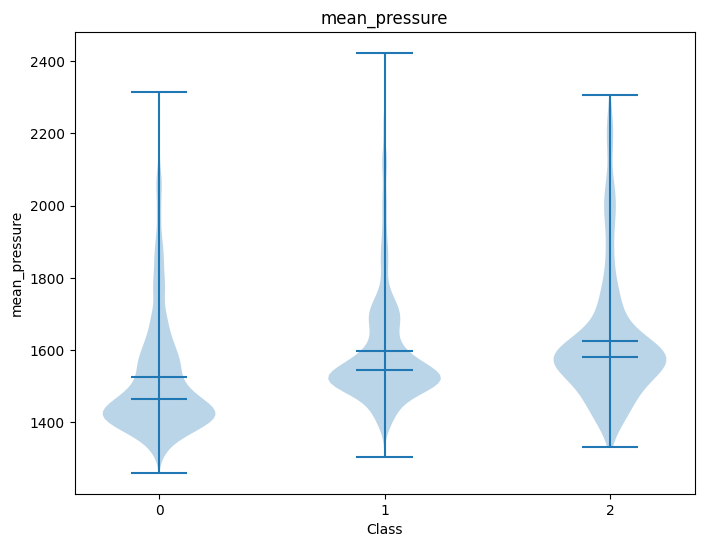

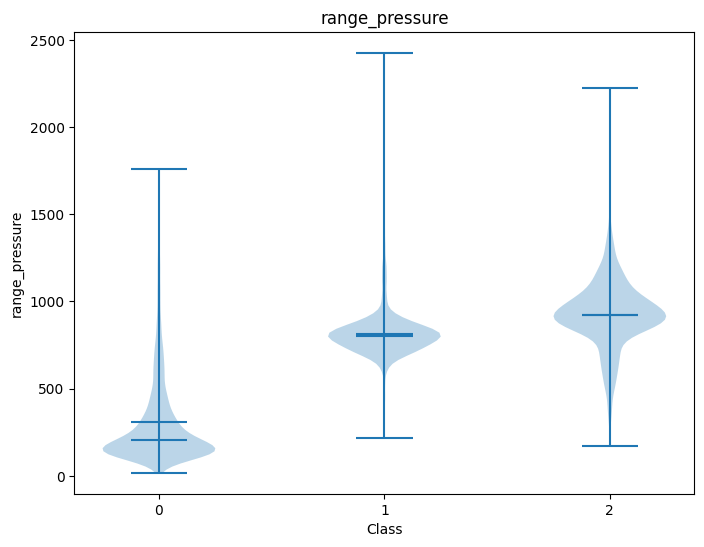

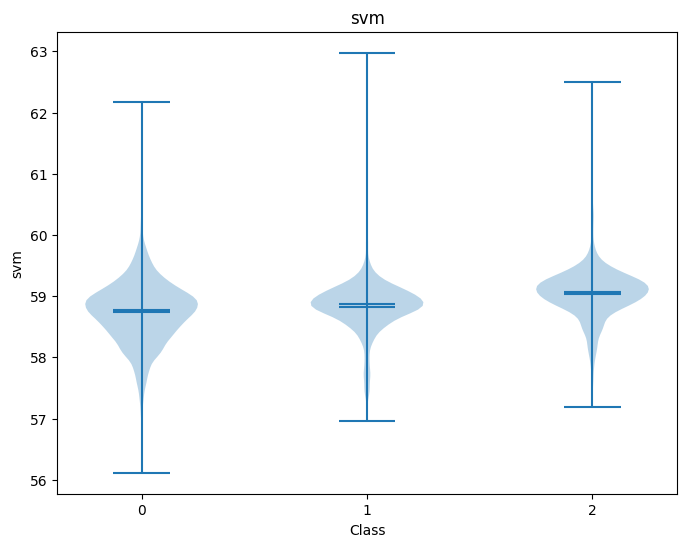

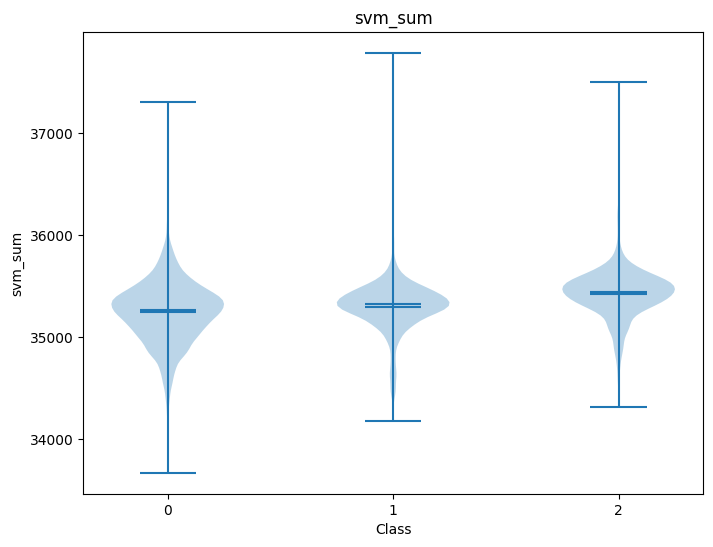

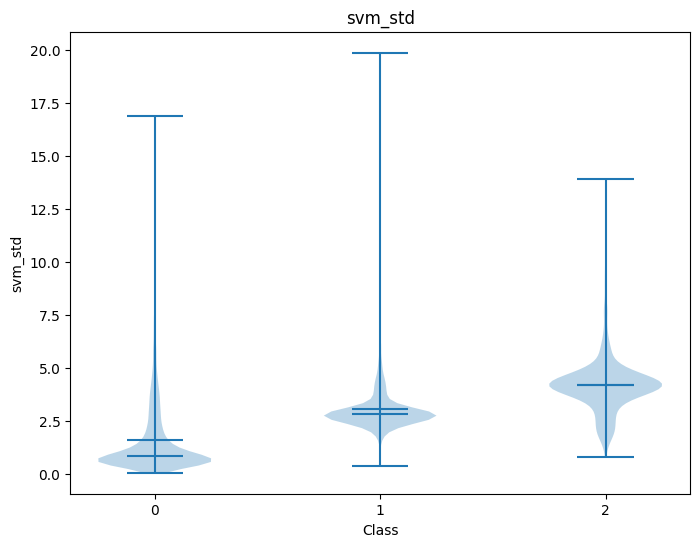

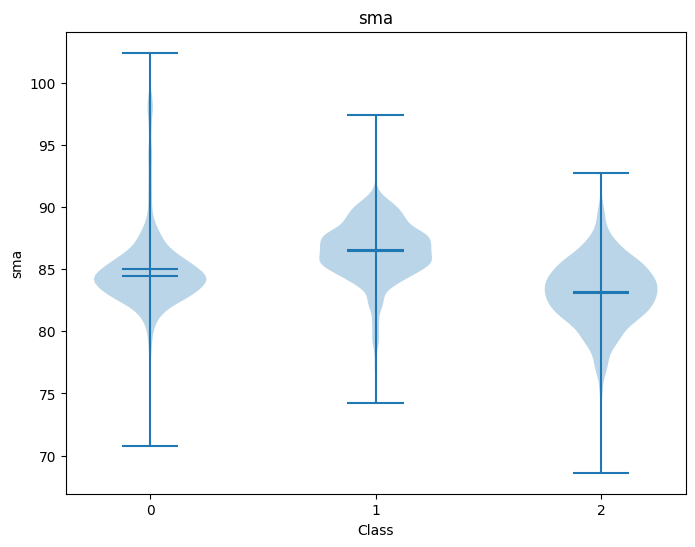

In [17]:
for var in ['odba', 'mean_pressure', 'range_pressure', 'svm', 'svm_sum', 'svm_std', 'sma']:
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_df = X_train.copy()
    plot_df["classification"] = y_train.to_numpy()
    
    # Prepare data for violin plot
    data_by_class = [plot_df[plot_df["classification"] == cls][var].values for cls in sorted(plot_df["classification"].unique())]
    
    ax.violinplot(data_by_class, positions=sorted(plot_df["classification"].unique()), showmeans=True, showmedians=True)
    ax.set_xlabel("Class")
    ax.set_ylabel(var)
    ax.set_title(var)
    ax.set_xticks(sorted(plot_df["classification"].unique()))

plt.show()


## Train a simple classification model
A simple benchmark for classification tasks is the "majority class" model, which always predicts the most frequent class in the training data. This provides a baseline to compare more advanced models against. If your classifier cannot outperform this naive approach, it may not be learning meaningful patterns from the data.

**TASK**
Implement the majority class benchmark model below. Report the accuracy on the test set.

In [18]:
# Add your code here

## Train a Random Forest Classification Model

For the next step, you will train a Random Forest classifier.

**TASK**
Build a classification pipeline that applies `StandardScaler` and then `RandomForestClassifier`.
Use a pipeline, fit on the training data and use it for prediction on the test data.

In [20]:
# Add your code here
# rf = Pipeline([

**Task**
Apply the random forest model ("rf") on the test data and store the predictions in "y_pref_rf". Evaluate the performance of the model and report the accuracy, and provide a classification report.

In [22]:
# Put your code here


**Task**
Analyze which behaviour class is predicted best and which is predicted worst.  

Try applying SMOTE upsampling on the training data, retrain the model, and evaluate the effect by comparing metrics before and after upsampling. Since SMOTE is distance based, it is recommended to scale the data.

In [24]:
# Put your code here

# rf_smote = Pipeline([

Below we will also fit the ROC and precision-recall curves before and after SMOTE. These graphs clearly illustrate the trade-off between recall and sensitivity. Moreover it also illustrates that solely using the ROC-curve is not appropriate to assess model performance when it concerns to imbalanced data.

,model,class,label,roc_auc,average_precision,youden_threshold,youden_fpr,youden_tpr,youden_index
3,After SMOTE,0,Other activity,0.982455,0.984796,0.384,0.074863,0.946874,0.872011
0,Before SMOTE,0,Other activity,0.982929,0.984558,0.444,0.082062,0.952509,0.870447
4,After SMOTE,1,Rumination,0.965772,0.953001,0.336,0.066162,0.853191,0.787029
1,Before SMOTE,1,Rumination,0.968578,0.957113,0.388,0.076409,0.871634,0.795225
5,After SMOTE,2,Ingestive behaviour,0.934559,0.607587,0.218,0.136844,0.891076,0.754232
2,Before SMOTE,2,Ingestive behaviour,0.936699,0.614246,0.144,0.143212,0.898950,0.755738


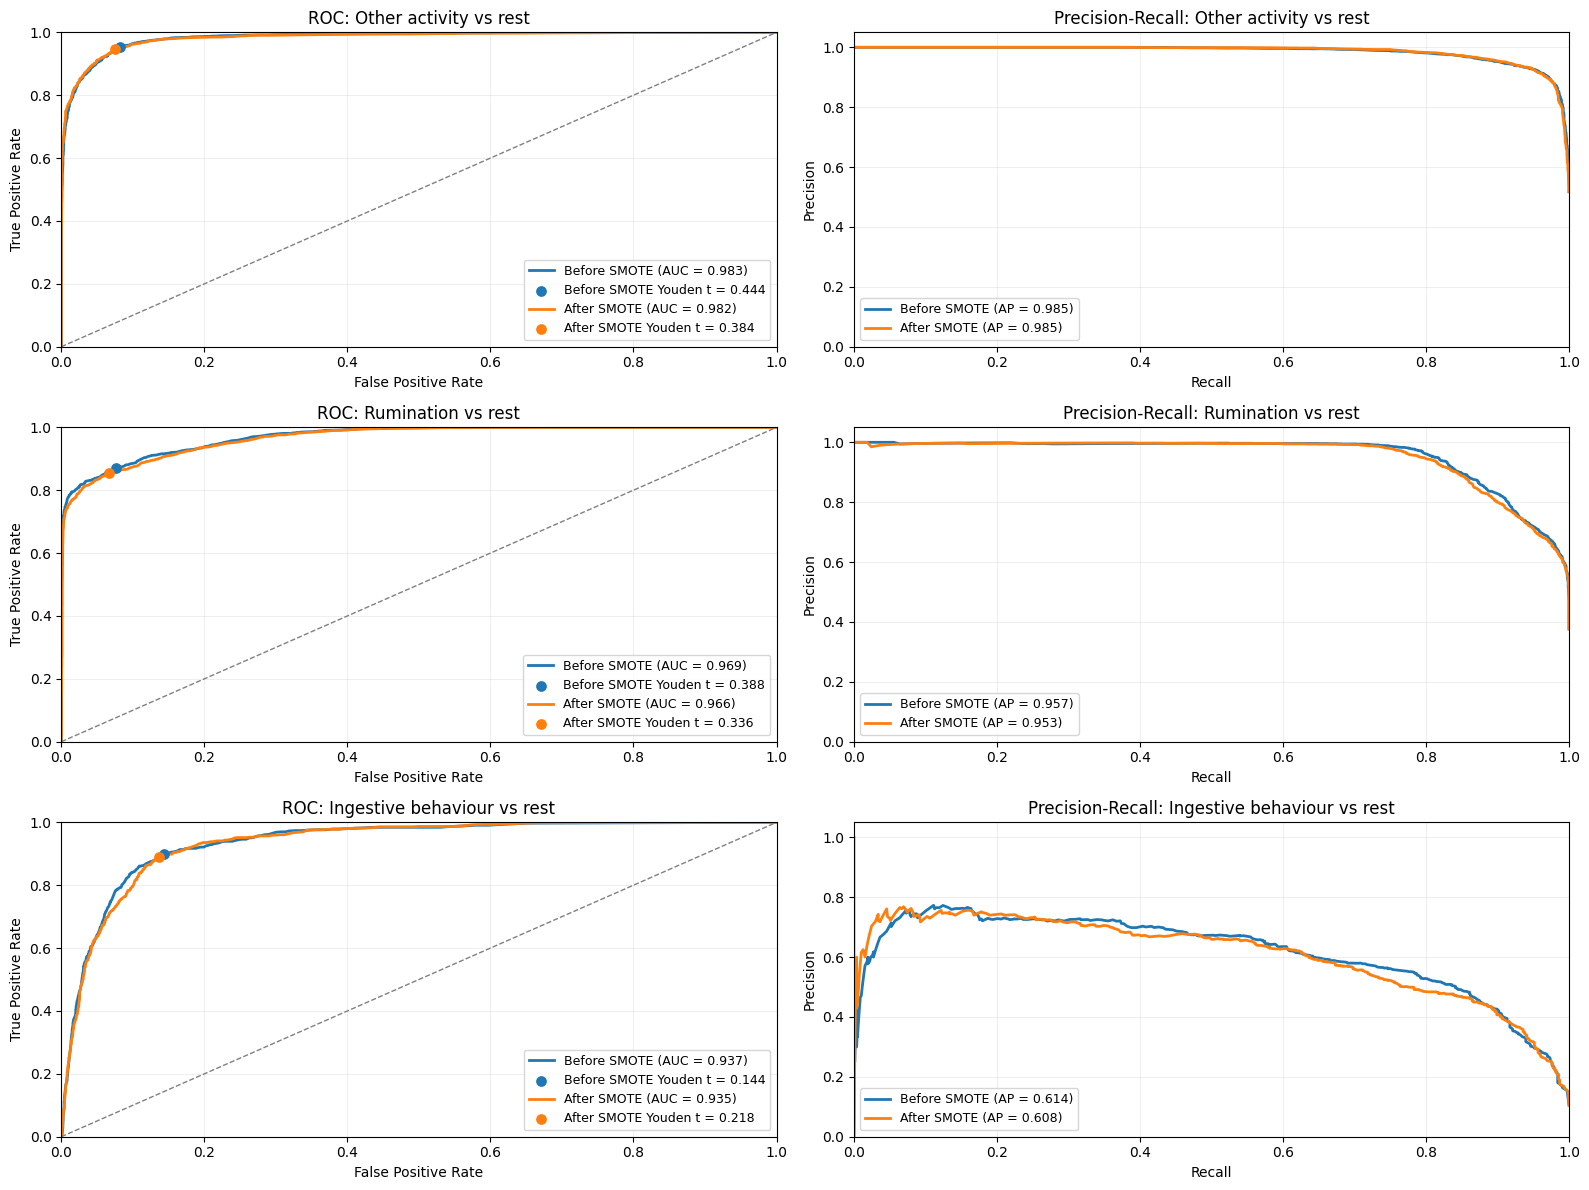

In [26]:
classes = sorted(class_mapping.keys())
model_specs = {
    'Before SMOTE': rf,
    'After SMOTE': rf_smote,
}

def collect_one_vs_rest_curves(model, X, y_true, class_labels):
    """Return ROC, PR, AUC, AP, and Youden summaries for each one-vs-rest class."""
    model_classes = model.named_steps['rf'].classes_
    probabilities = model.predict_proba(X)
    results = {}

    for cls in class_labels:
        class_index = np.where(model_classes == cls)[0][0]
        y_binary = (y_true == cls).astype(int).to_numpy()
        y_score = probabilities[:, class_index]

        fpr, tpr, roc_thresholds = roc_curve(y_binary, y_score)
        precision, recall, pr_thresholds = precision_recall_curve(y_binary, y_score)
        roc_auc = auc(fpr, tpr)
        average_precision = average_precision_score(y_binary, y_score)
        youden_index = tpr - fpr
        best_idx = int(np.argmax(youden_index))

        results[cls] = {
            'fpr': fpr,
            'tpr': tpr,
            'roc_thresholds': roc_thresholds,
            'precision': precision,
            'recall': recall,
            'pr_thresholds': pr_thresholds,
            'roc_auc': roc_auc,
            'average_precision': average_precision,
            'best_idx': best_idx,
            'best_threshold': roc_thresholds[best_idx],
            'best_fpr': fpr[best_idx],
            'best_tpr': tpr[best_idx],
            'best_youden': youden_index[best_idx],
        }

    return results

curve_results = {}
summary_rows = []

for model_name, model in model_specs.items():
    curve_results[model_name] = collect_one_vs_rest_curves(model, X_test, y_test, classes)
    for cls in classes:
        summary_rows.append({
            'model': model_name,
            'class': cls,
            'label': class_mapping.get(cls, str(cls)),
            'roc_auc': curve_results[model_name][cls]['roc_auc'],
            'average_precision': curve_results[model_name][cls]['average_precision'],
            'youden_threshold': curve_results[model_name][cls]['best_threshold'],
            'youden_fpr': curve_results[model_name][cls]['best_fpr'],
            'youden_tpr': curve_results[model_name][cls]['best_tpr'],
            'youden_index': curve_results[model_name][cls]['best_youden'],
        })

summary_df = pd.DataFrame(summary_rows).sort_values(['class', 'model'])
display(summary_df)

fig, axes = plt.subplots(len(classes), 2, figsize=(16, 4 * len(classes)), squeeze=False)

for row, cls in enumerate(classes):
    label = class_mapping.get(cls, str(cls))
    roc_ax = axes[row, 0]
    pr_ax = axes[row, 1]

    for model_name, color in [('Before SMOTE', 'tab:blue'), ('After SMOTE', 'tab:orange')]:
        data = curve_results[model_name][cls]

        roc_ax.plot(
            data['fpr'],
            data['tpr'],
            label=f'{model_name} (AUC = {data["roc_auc"]:.3f})',
            color=color,
            linewidth=2,
        )
        roc_ax.scatter(
            data['best_fpr'],
            data['best_tpr'],
            color=color,
            marker='o',
            s=45,
            zorder=3,
            label=f'{model_name} Youden t = {data["best_threshold"]:.3f}',
        )

        pr_ax.plot(
            data['recall'][::-1],
            data['precision'][::-1],
            label=f'{model_name} (AP = {data["average_precision"]:.3f})',
            color=color,
            linewidth=2,
        )

    roc_ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    roc_ax.set_title(f'ROC: {label} vs rest')
    roc_ax.set_xlabel('False Positive Rate')
    roc_ax.set_ylabel('True Positive Rate')
    roc_ax.set_xlim(0, 1)
    roc_ax.set_ylim(0, 1)
    roc_ax.grid(True, alpha=0.2)
    roc_ax.legend(fontsize=9, loc='lower right')

    pr_ax.set_title(f'Precision-Recall: {label} vs rest')
    pr_ax.set_xlabel('Recall')
    pr_ax.set_ylabel('Precision')
    pr_ax.set_xlim(0, 1)
    pr_ax.set_ylim(0, 1.05)
    pr_ax.grid(True, alpha=0.2)
    pr_ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

Interpretation of SMOTE
SMOTE has only a limited effect here. The one-vs-rest ROC and precision-recall curves improve only marginally for some classes, while the main ranking of the classes stays almost the same. In practice, this means the model already captures most of the signal from the engineered window features, so synthetic oversampling does not add much new information.

## Threshold tuning
The Youden index gives a class-specific decision threshold from the ROC curve. For the multiclass setting here, we can use those thresholds to bias the final label selection toward classes that need a lower or higher cutoff. This is of interest when the main issue is decision bias rather than missing signal. Although for the current exercise tuning the cut-off does not show any added value on top of SMOTE, we will still illustrate this principle.

In [27]:
# Compare default predictions with Youden-threshold-tuned predictions
def predict_with_youden_thresholds(model, X, thresholds_by_class):
    probabilities = model.predict_proba(X)
    model_classes = model.named_steps['rf'].classes_
    threshold_vector = np.array([thresholds_by_class[int(cls)] for cls in model_classes])
    adjusted_scores = probabilities - threshold_vector
    winner_index = np.argmax(adjusted_scores, axis=1)
    return model_classes[winner_index]

thresholds_before = {
    cls: curve_results['Before SMOTE'][cls]['best_threshold']
    for cls in classes
}
thresholds_after = {
    cls: curve_results['After SMOTE'][cls]['best_threshold']
    for cls in classes
}

y_pred_rf_youden = predict_with_youden_thresholds(rf, X_test, thresholds_before)
y_pred_rf_smote_youden = predict_with_youden_thresholds(rf_smote, X_test, thresholds_after)

threshold_summary = pd.DataFrame([
    {
        'model': 'Before SMOTE',
        'variant': 'Default',
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'macro_f1': f1_score(y_test, y_pred_rf, average='macro'),
    },
    {
        'model': 'Before SMOTE',
        'variant': 'Youden tuned',
        'accuracy': accuracy_score(y_test, y_pred_rf_youden),
        'macro_f1': f1_score(y_test, y_pred_rf_youden, average='macro'),
    },
    {
        'model': 'After SMOTE',
        'variant': 'Default',
        'accuracy': accuracy_score(y_test, y_pred_rf_smote),
        'macro_f1': f1_score(y_test, y_pred_rf_smote, average='macro'),
    },
    {
        'model': 'After SMOTE',
        'variant': 'Youden tuned',
        'accuracy': accuracy_score(y_test, y_pred_rf_smote_youden),
        'macro_f1': f1_score(y_test, y_pred_rf_smote_youden, average='macro'),
    },
]).sort_values(['model', 'variant'])

display(threshold_summary)

print('Before SMOTE, default classification report:')
print(classification_report(y_test, y_pred_rf, digits=3))

print('\nBefore SMOTE, Youden-tuned classification report:')
print(classification_report(y_test, y_pred_rf_youden, digits=3))

print('\nAfter SMOTE, default classification report:')
print(classification_report(y_test, y_pred_rf_smote, digits=3))

print('\nAfter SMOTE, Youden-tuned classification report:')
print(classification_report(y_test, y_pred_rf_smote_youden, digits=3))

,model,variant,accuracy,macro_f1
2,After SMOTE,Default,0.874028,0.809655
3,After SMOTE,Youden tuned,0.865694,0.802970
0,Before SMOTE,Default,0.880417,0.806990
1,Before SMOTE,Youden tuned,0.874583,0.815086


Before SMOTE, default classification report:
              precision    recall  f1-score   support

           0      0.915     0.958     0.936      3727
           1      0.904     0.853     0.878      2711
           2      0.616     0.598     0.607       762

    accuracy                          0.880      7200
   macro avg      0.812     0.803     0.807      7200
weighted avg      0.879     0.880     0.879      7200


Before SMOTE, Youden-tuned classification report:
              precision    recall  f1-score   support

           0      0.935     0.937     0.936      3727
           1      0.950     0.810     0.875      2711
           2      0.527     0.797     0.635       762

    accuracy                          0.875      7200
   macro avg      0.804     0.848     0.815      7200
weighted avg      0.897     0.875     0.881      7200


After SMOTE, default classification report:
              precision    recall  f1-score   support

           0      0.931     0.942     0.93

## Confusion matrix

**TASK**
Plot the confusion matrix of the model with and without smote. Use a heatmap for better visualization.

Without smote

In [28]:
# Put your code here

With smote

In [30]:
# Put your code here

## Feature Importance Analysis

**TASK**
Analyze and plot feature importances for the smote random forest model.

In [32]:
# Put your code here

## Model visualisation and interpretation

**TASK**
To finish: Make a line plot of the observed an predicted minutes spent ruminating per hour for the test set. Use your best model for the predictions. The x-axis should represent the time (in hours) and the y-axis should represent the minutes spent ruminating. Include a legend to differentiate between observed and predicted values.


In [34]:
# Add your code here